# 7. Resultados: Perfilado de los Cuatro Segmentos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/customers_segmentados.csv')
dfp = pd.read_pickle('../data/processed/df_processed.pkl')
dfp = dfp.merge(df[['fullVisitorId', 'cluster', 'cluster_name']], on='fullVisitorId')

cluster_names = {0: 'Desktop Engaged', 1: 'Desktop Frecuente',
                 2: 'Weekend Warriors', 3: 'Mobile Users'}
print(f"Dataset segmentado: {len(df):,} visitantes, {df['cluster'].nunique()} clusters")


Dataset segmentado: 9,996 visitantes, 4 clusters


In [2]:
# Tabla de perfiles numéricos
num_cols = ['n_sessions', 'totals.hits', 'totals.pageviews', 'bounce_prop', 'weekend_prop']
profiles = dfp.groupby('cluster')[num_cols].agg(['mean', 'median', 'std']).round(3)
display(profiles)


n_sessions               totals.hits                totals.pageviews  \
              mean median    std        mean median     std             mean   
cluster                                                                        
0            1.646    1.0  0.894      31.592   26.0  19.101           24.556   
1            5.879    5.0  4.046       9.071    8.0   5.867            7.645   
2            1.687    2.0  0.820      32.253   26.5  20.594           25.041   
3            3.234    2.0  3.229      17.933   15.0  14.700           14.700   

                       bounce_prop               weekend_prop                
        median     std        mean median    std         mean median    std  
cluster                                                                      
0         21.0  13.358       0.013  0.000  0.076        0.008    0.0  0.049  
1          7.0   4.524       0.153  0.083  0.186        0.097    0.0  0.174  
2         21.0  14.237       0.028  0.000  0.108        0.849    1.0  0.222  
3         13.0  11.115       0.167  0.000  0.222        0.250    0.0  0.358

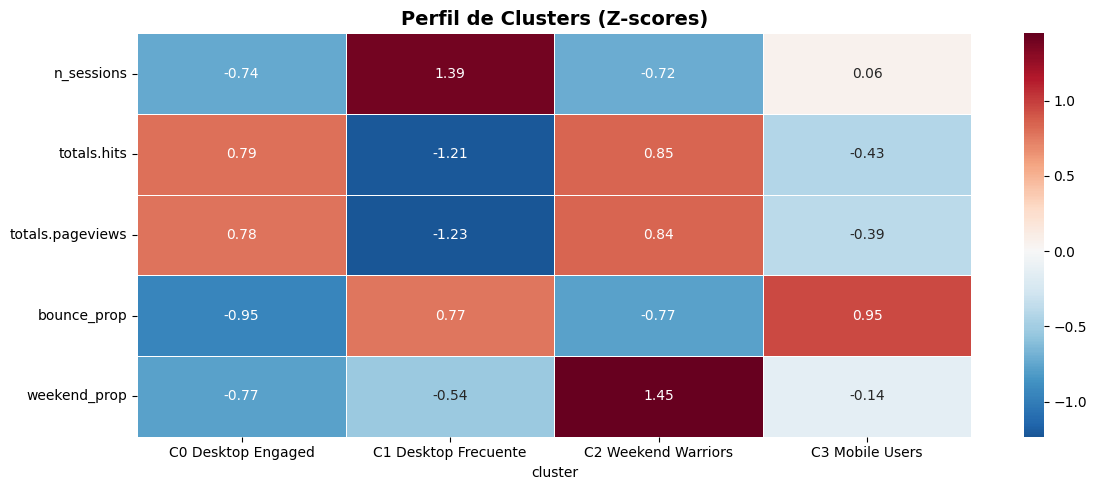

In [3]:
# Heatmap de perfiles (z-score por variable)
profile_means = dfp.groupby('cluster')[num_cols].mean()
profile_z = (profile_means - profile_means.mean()) / profile_means.std()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(profile_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=[f'C{i} {cluster_names[i]}' for i in range(4)],
            ax=ax, linewidths=0.5)
ax.set_title('Perfil de Clusters (Z-scores)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/heatmap_perfiles.png', dpi=150, bbox_inches='tight')
plt.show()


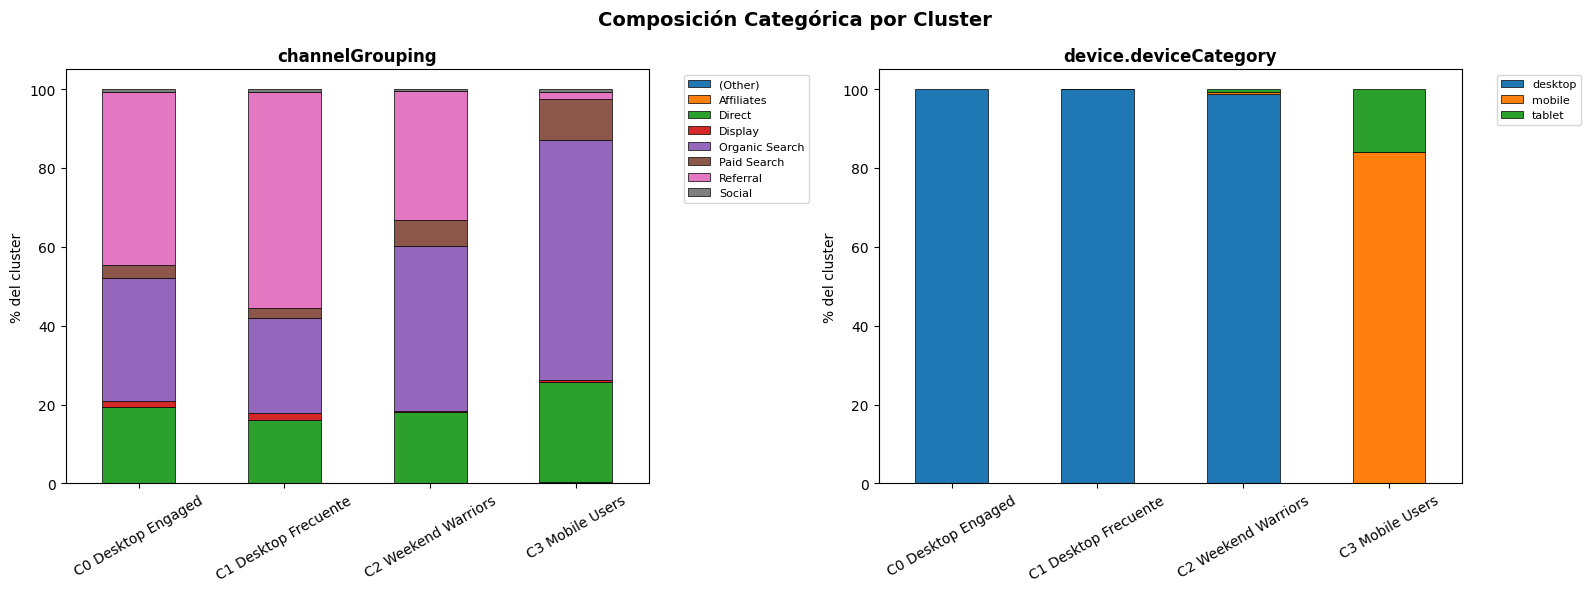

In [4]:
# Composición categórica
cat_cols = ['channelGrouping', 'device.deviceCategory']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(dfp['cluster'], dfp[col], normalize='index') * 100
    ct.index = [f'C{j} {cluster_names[j]}' for j in ct.index]
    ct.plot(kind='bar', stacked=True, ax=axes[i], edgecolor='black', linewidth=0.5)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('% del cluster')
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle('Composición Categórica por Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/03_composicion_categorica.png', dpi=150, bbox_inches='tight')
plt.show()


## Resumen de Segmentos

| Cluster | Nombre | % | Perfil |
|---------|--------|---|--------|
| C0 | Desktop Engaged | 42.5% | Alto engagement desktop, bajo bounce (1.3%), navegan entre semana, llegan por referral |
| C1 | Desktop Frecuente | 38.2% | Frecuentes pero superficiales, bounce alto (15.3%), desktop, muchas sesiones |
| C2 | Weekend Warriors | 9.7% | Navegan 85% en fin de semana, engagement alto similar a C0, bounce bajo |
| C3 | Mobile Users | 9.6% | 84% mobile, bounce alto (16.7%), sesiones cortas, llegan por organic search |

**Hallazgo clave**: C0 y C2 son funcionalmente similares en engagement — la única diferencia real es el **momento** (entre semana vs fin de semana).


# 8. Recomendaciones de Marketing


## C0 — Desktop Engaged (42.5%)
**Canal**: Email marketing + retargeting display  
**Timing**: Horario laboral 9-18h, entre semana  
**Mensaje**: Contenido profundo: guías de producto, comparativas, programa de lealtad  
**KPIs**: Páginas por sesión, tiempo en sitio, tasa de conversión  
**Budget**: Alto — son los más propensos a convertir

## C1 — Desktop Frecuente (38.2%)
**Canal**: Push notifications + email con CTAs directos  
**Timing**: Horario laboral, primeras horas  
**Mensaje**: Ofertas directas, urgencia, descuentos por frecuencia  
**KPIs**: Profundidad de navegación, reducción de bounce, conversión  
**Budget**: Medio — volumen alto pero conversión incierta

## C2 — Weekend Warriors (9.7%)
**Canal**: Social media + display ads en fin de semana  
**Timing**: Viernes tarde a domingo  
**Mensaje**: Promociones de fin de semana, flash sales, contenido lifestyle  
**KPIs**: CTR fin de semana, engagement social, ticket promedio  
**Budget**: Medio — ventana temporal limitada pero predecible

## C3 — Mobile Users (9.6%)
**Canal**: SMS + push mobile + social stories  
**Timing**: Horarios de commute (7-9h, 17-19h) y noche (21-23h)  
**Mensaje**: Micro-contenido, CTAs de un solo tap, experiencia mobile-first  
**KPIs**: Conversión mobile, bounce rate mobile, app installs  
**Budget**: Medio-bajo — optimizar UX mobile antes de invertir

### Recomendación Transversal
**Priorizar dispositivo sobre canal** en la asignación de presupuesto. El análisis estadístico muestra que `device.deviceCategory` (Cramer's V ≈ 0.70) es un separador mucho más fuerte que `channelGrouping` (V ≈ 0.19).


# 9. Limitaciones

1. **Ausencia de datos de conversión/revenue/LTV**: no podemos asignar valor monetario a cada segmento
2. **Sesgo del dataset**: probablemente proviene de Google Merchandise Store, un sitio atípico
3. **Falta de validación cualitativa**: los segmentos no han sido validados con stakeholders de negocio
4. **Segmentos mobile pequeños**: C3 tiene solo 957 visitantes (9.6%), lo que limita la granularidad
5. **Datos estáticos**: no hay dimensión temporal para detectar drift o estacionalidad


# 10. Conclusiones y Siguientes Pasos

## Hallazgos principales
- 4 segmentos accionables con KMeans, validados por bootstrap (ARI 0.97) y tests estadísticos
- El **dispositivo** es un separador más fuerte que el **canal** de tráfico
- C0 y C2 son funcionalmente equivalentes en engagement; la diferencia es temporal
- Todas las diferencias entre clusters son estadísticamente significativas con effect sizes medianos a grandes

## Siguientes pasos
1. **Validación cualitativa** con el equipo de marketing/producto
2. **Integración con datos de conversión** (RFM, LTV) para priorizar segmentos por valor
3. **Drift detection**: monitorear la estabilidad de los clusters trimestralmente
4. **A/B testing**: probar las recomendaciones de marketing por segmento
5. **Re-entrenamiento**: actualizar el modelo cada trimestre con datos frescos
